In [ ]:
# Task 1
import pandas as pd

df = pd.read_csv("heart.csv")

print("First 5 rows of the dataset:")
print(df.head())

print("\nColumn Names:")
print(df.columns)

print("\nOriginal Data Types:")
print(df.dtypes)

categorical_columns = [
    "Gender",
    "education",
    "currentSmoker",
    "BPMeds",
    "prevalentStroke",
    "prevalentHyp",
    "diabetes",
    "Heart_ stroke"
]

for col in categorical_columns:
    df[col] = df[col].astype("category")

print("\nUpdated Data Types:")
print(df.dtypes)

print("\nFinal Dataset:")
print(df.head())

First 5 rows of the dataset:
   Gender  age      education  currentSmoker  cigsPerDay  BPMeds  \
0    Male   39   postgraduate              0         0.0     0.0   
1  Female   46  primaryschool              0         0.0     0.0   
2    Male   48     uneducated              1        20.0     0.0   
3  Female   61       graduate              1        30.0     0.0   
4  Female   46       graduate              1        23.0     0.0   

  prevalentStroke  prevalentHyp  diabetes  totChol  sysBP  diaBP    BMI  \
0              no             0         0    195.0  106.0   70.0  26.97   
1              no             0         0    250.0  121.0   81.0  28.73   
2              no             0         0    245.0  127.5   80.0  25.34   
3              no             1         0    225.0  150.0   95.0  28.58   
4              no             0         0    285.0  130.0   84.0  23.10   

   heartRate  glucose Heart_ stroke  
0       80.0     77.0            No  
1       95.0     76.0            No


totChol
Q1: 206.0
Q3: 263.0
IQR: 57.0
Lower Bound: 120.5
Upper Bound: 348.5
Number of Outliers: 56

heartRate
Q1: 68.0
Q3: 83.0
IQR: 15.0
Lower Bound: 45.5
Upper Bound: 105.5
Number of Outliers: 76


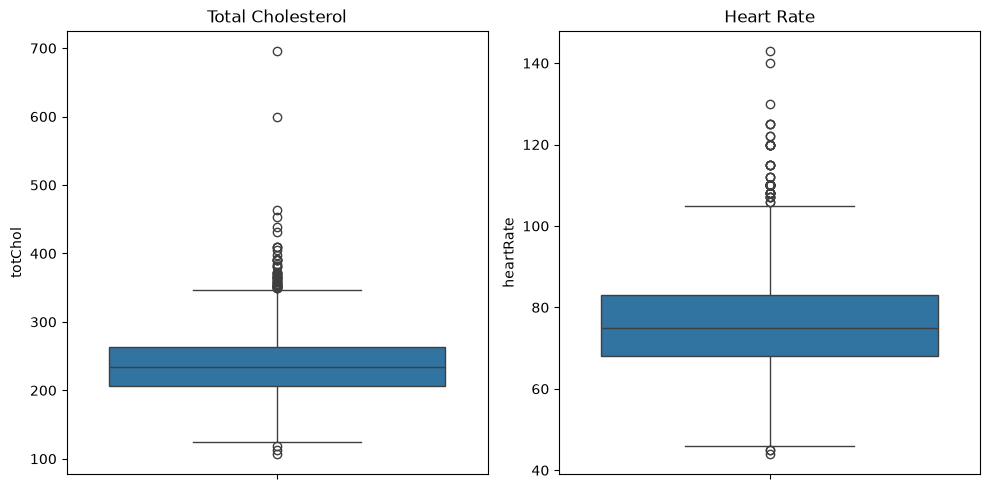

In [4]:
# Task 2
import matplotlib.pyplot as plt
import seaborn as sns

def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower) |
        (df[column] > upper)
    ]

    print(f"\n{column}")
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower Bound:", lower)
    print("Upper Bound:", upper)
    print("Number of Outliers:", len(outliers))

    return outliers


chol_outliers = detect_outliers_iqr(df, "totChol")
heart_rate_outliers = detect_outliers_iqr(df, "heartRate")

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
sns.boxplot(y=df["totChol"])
plt.title("Total Cholesterol")

plt.subplot(1, 2, 2)
sns.boxplot(y=df["heartRate"])
plt.title("Heart Rate")

plt.tight_layout()
plt.show()

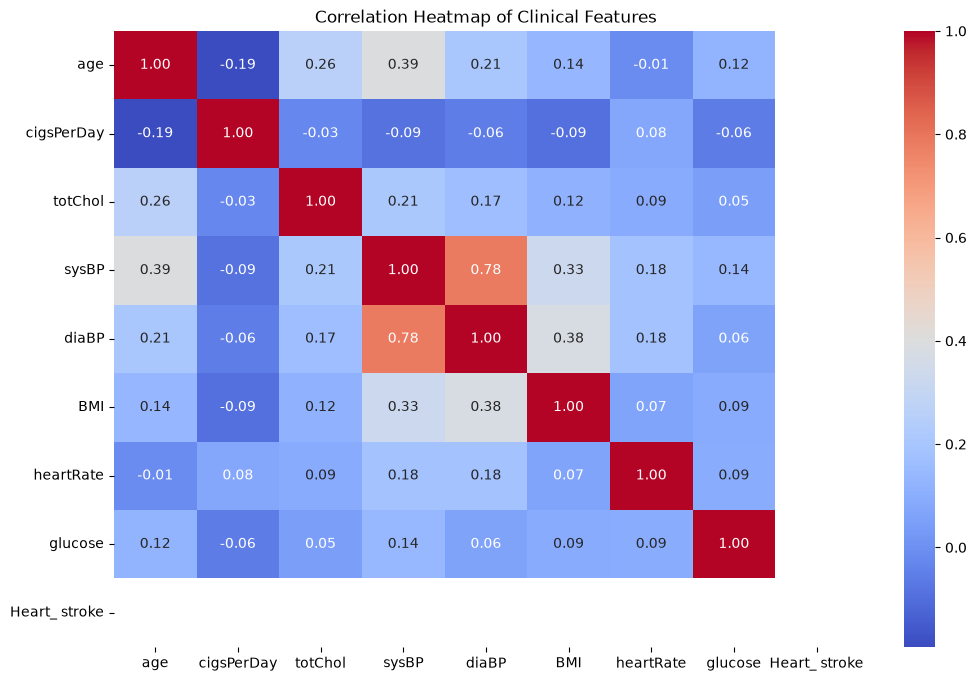

Correlation with Heart Stroke:
age             NaN
cigsPerDay      NaN
totChol         NaN
sysBP           NaN
diaBP           NaN
BMI             NaN
heartRate       NaN
glucose         NaN
Heart_ stroke   NaN
Name: Heart_ stroke, dtype: float64


In [ ]:
# Task 3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df["Heart_ stroke"] = df["Heart_ stroke"].map({
    "No": 0,
    "yes": 1
})

numeric_df = df.select_dtypes(include="number")

correlation = numeric_df.corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Clinical Features")
plt.show()

print("Correlation with Heart Stroke:")
print(
    correlation["Heart_ stroke"]
    .sort_values(ascending=False)
)

In [ ]:
# Task 4
import pandas as pd
from sklearn.preprocessing import StandardScaler

df["Age-adjusted Max Heart Rate"] = df["heartRate"] / df["age"]

scaling_columns = [
    "age",
    "totChol",
    "heartRate",
    "Age-adjusted Max Heart Rate"
]

scaler = StandardScaler()

df[scaling_columns] = scaler.fit_transform(
    df[scaling_columns]
)

print(df[scaling_columns].head())

        age   totChol  heartRate  Age-adjusted Max Heart Rate
0 -1.234951 -0.935776   0.342704                     1.268612
1 -0.418257  0.297822   1.590087                     1.305917
2 -0.184916  0.185677  -0.073090                    -0.039864
3  1.331800 -0.262904  -0.904679                    -1.370142
4 -0.418257  1.082840   0.758498                     0.723958
